In [22]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.mtdna_theory import theoretical_probability_by_time

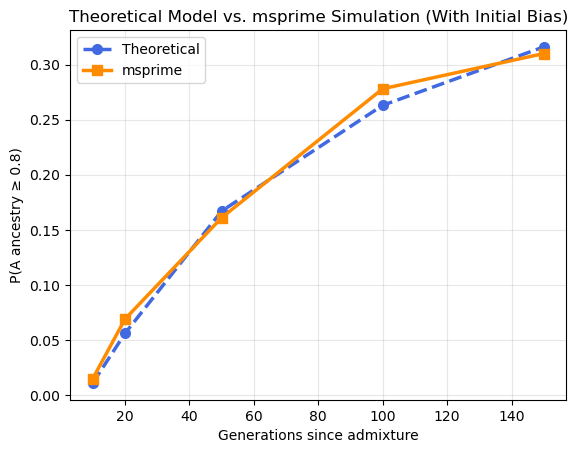

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from src.mtdna_msprime import prob_A_above_threshold
from src.mtdna_theory import theoretical_probability_by_time

RUN_SIM = 0

times = [10,20,50,100,150] 
N = 1000 
reps = 1000
threshold = 0.8
SPLIT_TIME = 200 
p_A = 0.7 

if RUN_SIM:
    theoretical_results_with_bias = theoretical_probability_by_time(times, N, p_A, threshold)
    msprime_results_with_bias = prob_A_above_threshold(times, N, reps, threshold, SPLIT_TIME, p_A)
else:
    theoretical_results_with_bias = {
    10: 0.011,
    20: 0.056,
    50: 0.167,
    100: 0.263,
    150: 0.316,
}

msprime_results_with_bias = {
    10: 0.015,
    20: 0.069,
    50: 0.161,
    100: 0.278,
    150: 0.310,
}

df = pd.DataFrame({
    "generation": list(theoretical_results_with_bias.keys()),
    "theoretical": list(theoretical_results_with_bias.values()),
    "msprime": list(msprime_results_with_bias.values()),
})


plt.plot(df["generation"], df["theoretical"], marker="o", linestyle="--", linewidth=2.5, markersize=7, color="royalblue", label="Theoretical")
plt.plot(df["generation"], df["msprime"], marker="s", linestyle="-", linewidth=2.5, markersize=7, color="darkorange", label="msprime")

plt.xlabel("Generations since admixture")
plt.ylabel("P(A ancestry ≥ 0.8)")
plt.title("Theoretical Model vs. msprime Simulation (With Initial Bias)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
